In [ ]:
# Student Performance Analysis & Prediction
## DECODE Data Science Bootcamp 2026

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, OrdinalEncoder
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


In [6]:
df = pd.read_excel("student_performance_dataset.xlsx")

print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMN NAMES & DTYPES ===")
print(df.info())

print("\n=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== LAST 5 ROWS ===")
print(df.tail())

print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())


=== SHAPE ===
(205, 14)

=== COLUMN NAMES & DTYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         205 non-null    int64  
 1   Name               205 non-null    object 
 2   Age                205 non-null    object 
 3   Gender             205 non-null    object 
 4   City               205 non-null    object 
 5   Department         205 non-null    object 
 6   Education_Level    205 non-null    object 
 7   Attendance_%       189 non-null    float64
 8   Study_Hours_Daily  200 non-null    float64
 9   Assignments        195 non-null    float64
 10  Quizzes            205 non-null    int64  
 11  Midterm            195 non-null    float64
 12  Internet_Access    205 non-null    object 
 13  Final_Score        205 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 22.6+ KB
None

===

In [7]:
# --- FIX 1: Gender casing ---
# Problem: male, MALE, female, FEMALE are all the same value
# Fix: .str.title() converts to "Male" / "Female" consistently
# Why title() not upper/lower? Because "Male"/"Female" is the readable standard
df['Gender'] = df['Gender'].str.title()
print("Gender unique values:", df['Gender'].unique())

Gender unique values: ['Female' 'Male']


In [8]:
# --- FIX 2: Name casing ---
# Problem: names in ALL CAPS or all lowercase (e.g., "ZAHID", "sara")
# Fix: .str.title() makes it "Zahid", "Sara" — proper name format
df['Name'] = df['Name'].str.title()
print("Sample names:", df['Name'].head(10).tolist())

Sample names: ['Uzma', 'Zahid', 'Sara', 'Zahid', 'Zahid', 'Rizwan', 'Hassan', 'Hira', 'Zahid', 'Hassan']


In [9]:
# --- FIX 3: Department inconsistencies ---
# Problem: "cs", "EE " (with space) instead of "CS", "EE"
# Fix: .str.upper() standardizes to uppercase, .str.strip() removes spaces
df['Department'] = df['Department'].str.upper().str.strip()
print("Department unique values:", df['Department'].unique())

Department unique values: ['CS' 'SE' 'BBA' 'EE' 'ME']


In [10]:
# --- FIX 4: Age has text values ---
# Problem: Age contains "twenty", "nineteen" as strings — can't do math on text
# Fix: pd.to_numeric with errors='coerce' converts text → NaN, then fill with median
# Why median? Age likely has a skewed distribution; median is more robust than mean
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
print("Age dtype:", df['Age'].dtype)
print("Age median used for fill:", age_median)

Age dtype: float64
Age median used for fill: 22.0


In [11]:
# --- FIX 5 & 6: Impossible values ---

# Attendance below 0 or above 100 is physically impossible
# Fix: Replace with NaN first, then fill with median
df.loc[df['Attendance_%'] < 0, 'Attendance_%'] = np.nan
df.loc[df['Attendance_%'] > 100, 'Attendance_%'] = np.nan

# Final_Score above 100 is also impossible (scale is 40-100 per project)
# Fix: Replace with NaN, then fill with median
df.loc[df['Final_Score'] > 100, 'Final_Score'] = np.nan

print("Attendance range after fix:", df['Attendance_%'].min(), "to", df['Attendance_%'].max())
print("Final_Score range after fix:", df['Final_Score'].min(), "to", df['Final_Score'].max())

Attendance range after fix: 55.0 to 99.0
Final_Score range after fix: 40.0 to 60.0


In [12]:
# --- FIX: Handle all missing values ---
# Fill numerical columns with their median
# Why median and not mean?
# → Mean is pulled by outliers. Our data had outliers (negative attendance, text ages).
# → Median is the middle value — it stays stable even with messy data.
# → For Final_Score, we already replaced impossible values with NaN above.

numerical_cols = ['Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Midterm', 'Final_Score']

for col in numerical_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled with median = {median_val}")

Attendance_%: filled with median = 79.0
Study_Hours_Daily: filled with median = 4.0
Assignments: filled with median = 7.0
Midterm: filled with median = 67.0
Final_Score: filled with median = 45.0


In [13]:
# --- FIX 7: Remove duplicate rows ---
# Why drop and not keep? Duplicates add no new information and bias the model
# They make it appear certain patterns are more common than they really are
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Rows before: {before}, Rows after: {after}, Duplicates removed: {before - after}")

Rows before: 205, Rows after: 200, Duplicates removed: 5


In [15]:
# --- FINAL CHECK ---
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nShape after cleaning:", df.shape)


Missing values after cleaning:
Student_ID           0
Name                 0
Age                  0
Gender               0
City                 0
Department           0
Education_Level      0
Attendance_%         0
Study_Hours_Daily    0
Assignments          0
Quizzes              0
Midterm              0
Internet_Access      0
Final_Score          0
dtype: int64

Shape after cleaning: (200, 14)


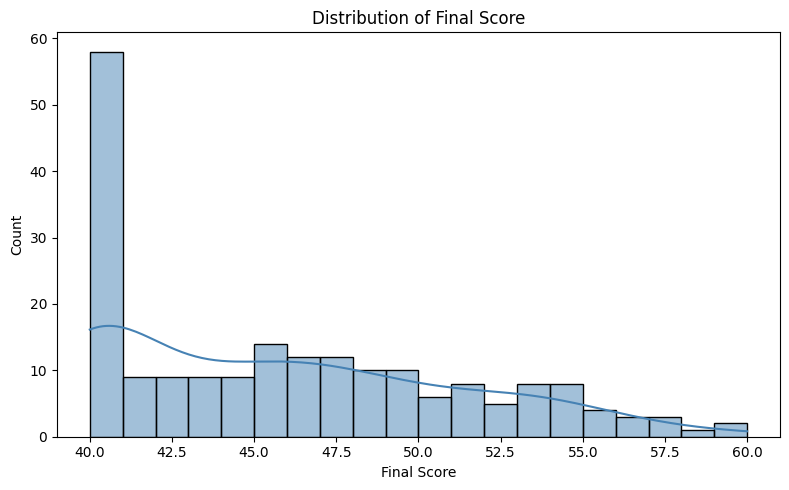

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Final_Score'], kde=True, color='steelblue', bins=20)
plt.title('Distribution of Final Score')
plt.xlabel('Final Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

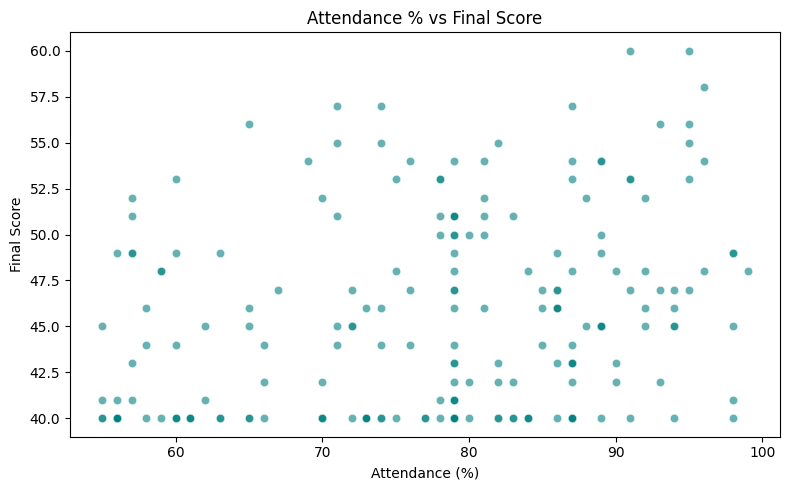

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Attendance_%', y='Final_Score', alpha=0.6, color='teal')
plt.title('Attendance % vs Final Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Final Score')
plt.tight_layout()
plt.show()

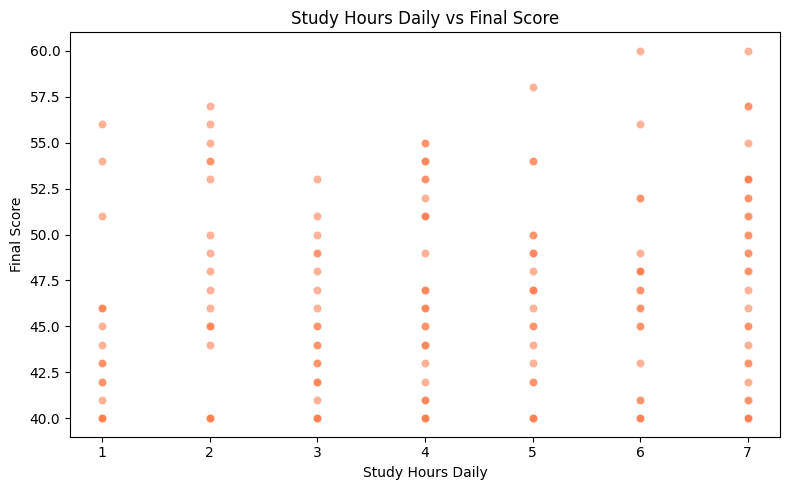

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Study_Hours_Daily', y='Final_Score', alpha=0.6, color='coral')
plt.title('Study Hours Daily vs Final Score')
plt.xlabel('Study Hours Daily')
plt.ylabel('Final Score')
plt.tight_layout()
plt.show()

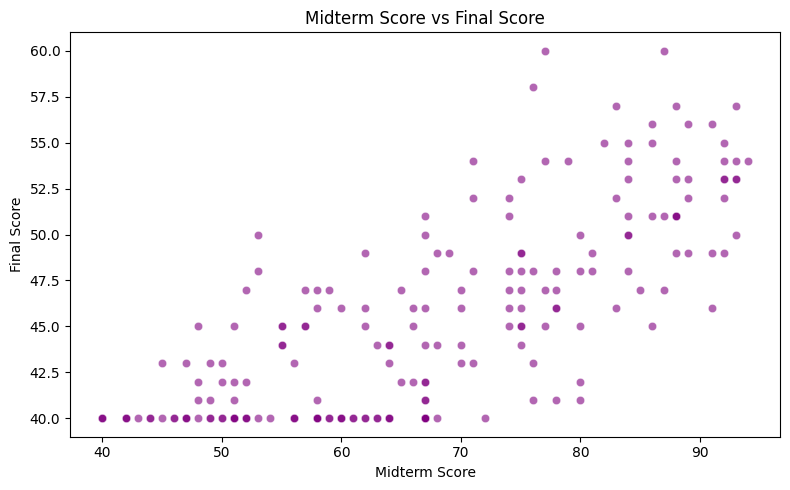

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Midterm', y='Final_Score', alpha=0.6, color='purple')
plt.title('Midterm Score vs Final Score')
plt.xlabel('Midterm Score')
plt.ylabel('Final Score')
plt.tight_layout()
plt.show()

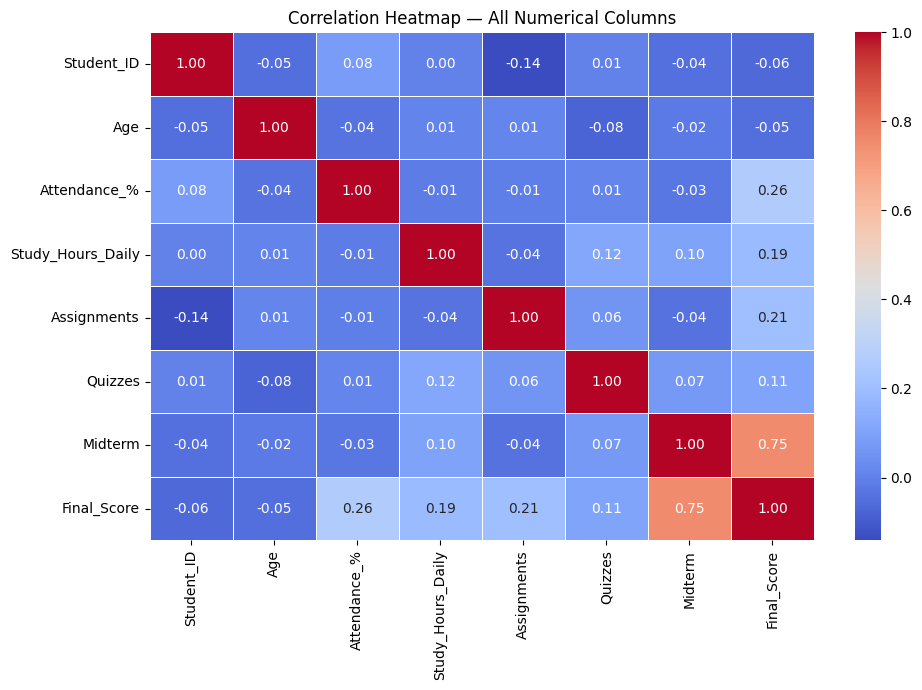

In [20]:
plt.figure(figsize=(10, 7))
numerical_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — All Numerical Columns')
plt.tight_layout()
plt.show()

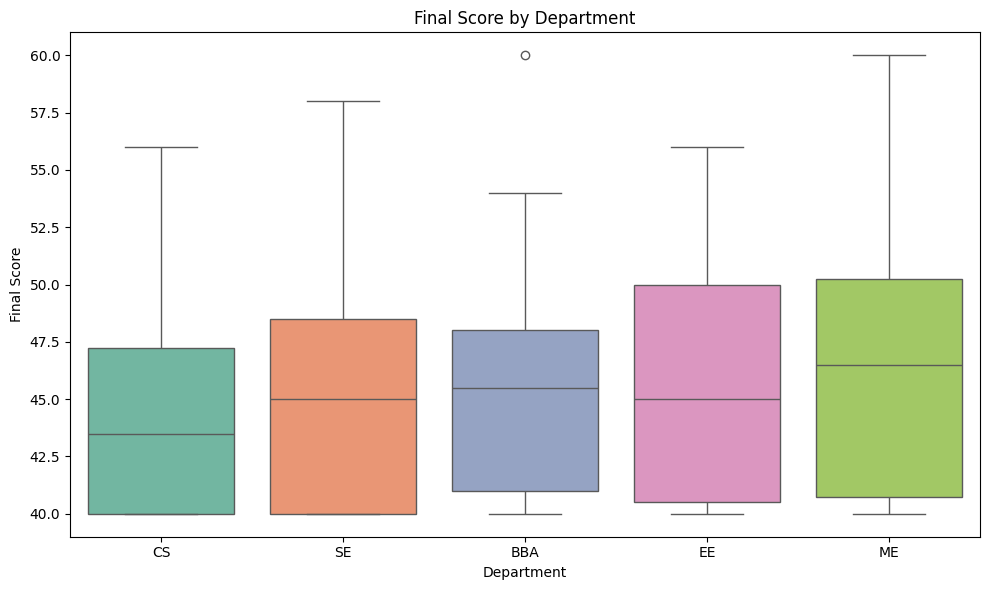

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Department', y='Final_Score', palette='Set2')
plt.title('Final Score by Department')
plt.xlabel('Department')
plt.ylabel('Final Score')
plt.tight_layout()
plt.show()

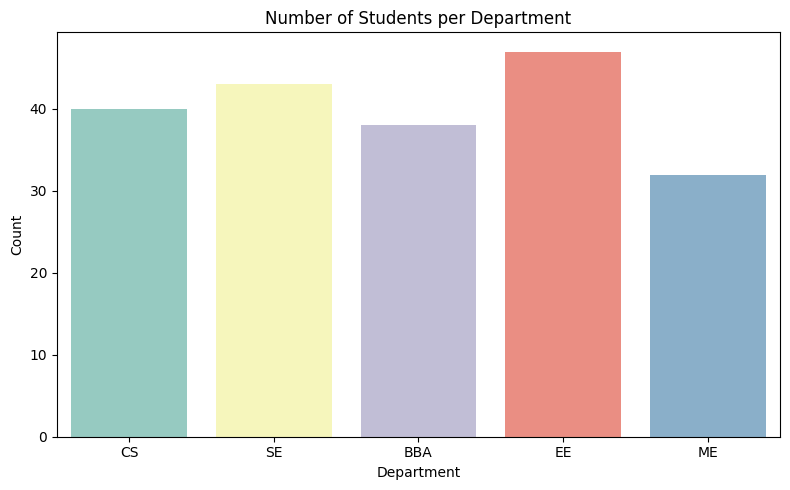

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Department', palette='Set3')
plt.title('Number of Students per Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [23]:
# Feature 1: Total_Academic — combines all graded components
# Formula given in project: Midterm + Assignments*5 + Quizzes*2
# Why? This creates a single "academic effort" score that weights heavier assessments more
df['Total_Academic'] = df['Midterm'] + df['Assignments'] * 5 + df['Quizzes'] * 2

# Feature 2: Attendance_Category — bin attendance into Low/Medium/High
# Why? Converts a continuous variable into an ordered group — useful for ordinal encoding
df['Attendance_Category'] = pd.cut(
    df['Attendance_%'],
    bins=[0, 60, 80, 100],
    labels=['Low', 'Medium', 'High']
)

print("Total_Academic sample values:")
print(df['Total_Academic'].head())
print("\nAttendance_Category value counts:")
print(df['Attendance_Category'].value_counts())

Total_Academic sample values:
0    145.0
1    129.0
2    118.0
3    124.0
4    134.0
Name: Total_Academic, dtype: float64

Attendance_Category value counts:
Attendance_Category
High      86
Medium    84
Low       30
Name: count, dtype: int64


In [24]:
# Drop Student_ID (just a row number, no predictive value)
# Drop Name (text, not useful for regression)
df_model = df.drop(columns=['Student_ID', 'Name'])

# Define target (what we want to predict)
X = df_model.drop(columns=['Final_Score'])
y = df_model['Final_Score']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:", X.columns.tolist())

Feature matrix shape: (200, 13)
Target shape: (200,)

Features: ['Age', 'Gender', 'City', 'Department', 'Education_Level', 'Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Quizzes', 'Midterm', 'Internet_Access', 'Total_Academic', 'Attendance_Category']


In [25]:
# Split BEFORE any transformation — to prevent data leakage
# Data leakage = when the model "sees" test data during training — gives fake good results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (160, 13)
Test size: (40, 13)


In [26]:
# Define which columns get which treatment

# One-Hot: no order between categories
onehot_cols = ['Gender', 'Internet_Access', 'City', 'Department']

# Ordinal: there IS a natural order
ordinal_education = ['Education_Level']
ordinal_attendance = ['Attendance_Category']

# Numerical: scale with StandardScaler
numerical_cols = ['Age', 'Attendance_%', 'Study_Hours_Daily',
                  'Assignments', 'Quizzes', 'Midterm', 'Total_Academic']

print("One-Hot columns:", onehot_cols)
print("Ordinal (Education):", ordinal_education)
print("Ordinal (Attendance):", ordinal_attendance)
print("Numerical:", numerical_cols)

One-Hot columns: ['Gender', 'Internet_Access', 'City', 'Department']
Ordinal (Education): ['Education_Level']
Ordinal (Attendance): ['Attendance_Category']
Numerical: ['Age', 'Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Quizzes', 'Midterm', 'Total_Academic']


In [28]:
# Build ColumnTransformer — applies different transformations to different columns
preprocessor = ColumnTransformer(transformers=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ordinal_edu', OrdinalEncoder(
        categories=[['Intermediate', 'Bachelors', 'Masters']]
    ), ordinal_education),
    ('ordinal_att', OrdinalEncoder(
        categories=[['Low', 'Medium', 'High']]
    ), ordinal_attendance),
    ('scaler', StandardScaler(), numerical_cols)
])

# Full Pipeline: preprocessing → model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

print("Pipeline built successfully!")
print(pipeline)


Pipeline built successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Internet_Access',
                                                   'City', 'Department']),
                                                 ('ordinal_edu',
                                                  OrdinalEncoder(categories=[['Intermediate',
                                                                              'Bachelors',
                                                                              'Masters']]),
                                                  ['Education_Level']),
                                                 ('ordinal_att',
                                                  OrdinalEncoder(categories=[['Low',
                                                                     

In [29]:
# Train the pipeline (fits preprocessor + model together on training data)
pipeline.fit(X_train, y_train)

# Predict on test data
y_pred = pipeline.predict(X_test)

# Print actual vs predicted for first 10 students
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10].round(2)})
print("Actual vs Predicted — First 10 Students:")
print(comparison)

Actual vs Predicted — First 10 Students:
   Actual  Predicted
0    52.0      53.30
1    47.0      52.54
2    40.0      46.17
3    48.0      45.33
4    42.0      41.54
5    43.0      42.65
6    50.0      48.02
7    53.0      50.70
8    45.0      46.71
9    41.0      49.64


In [30]:
# Extract the trained linear regression model from pipeline
trained_model = pipeline.named_steps['model']

print("Model Intercept (bias):", round(trained_model.intercept_, 4))
print("\nModel Coefficients (feature weights):")

# Get feature names from the preprocessor
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': trained_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df.to_string(index=False))

print("\n>>> Highest weight feature:", coef_df.iloc[0]['Feature'])
print("This means: a 1-unit increase in this feature increases Final_Score by", round(coef_df.iloc[0]['Coefficient'], 4))

Model Intercept (bias): 46.7574

Model Coefficients (feature weights):
                         Feature  Coefficient
                 scaler__Midterm     2.635667
            scaler__Attendance_%     1.883239
          scaler__Total_Academic     1.856096
         onehot__City_Rawalpindi     0.912470
           onehot__Department_ME     0.799209
             scaler__Assignments     0.521847
           onehot__Gender_Female     0.387355
       scaler__Study_Hours_Daily     0.358032
           onehot__Department_SE     0.352772
            onehot__City_Karachi     0.244124
      onehot__Internet_Access_No     0.091642
                     scaler__Age     0.075384
           onehot__Department_EE     0.059768
             onehot__City_Lahore     0.052671
     onehot__Internet_Access_Yes    -0.091642
          onehot__Department_BBA    -0.153053
    ordinal_edu__Education_Level    -0.156046
          onehot__City_Islamabad    -0.319917
             onehot__Gender_Male    -0.387355
         

In [31]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 40)
print("       MODEL EVALUATION REPORT")
print("=" * 40)
print(f"  MAE  (Mean Absolute Error):  {mae:.4f}")
print(f"  RMSE (Root Mean Sq Error):   {rmse:.4f}")
print(f"  R²   (Explained Variance):   {r2:.4f}")
print("=" * 40)
print("\nInterpretation:")
print(f"  → On average, predictions are off by {mae:.2f} points")
print(f"  → R² of {r2:.2f} means the model explains {r2*100:.1f}% of variance in Final_Score")

       MODEL EVALUATION REPORT
  MAE  (Mean Absolute Error):  2.4484
  RMSE (Root Mean Sq Error):   3.2652
  R²   (Explained Variance):   0.5866

Interpretation:
  → On average, predictions are off by 2.45 points
  → R² of 0.59 means the model explains 58.7% of variance in Final_Score


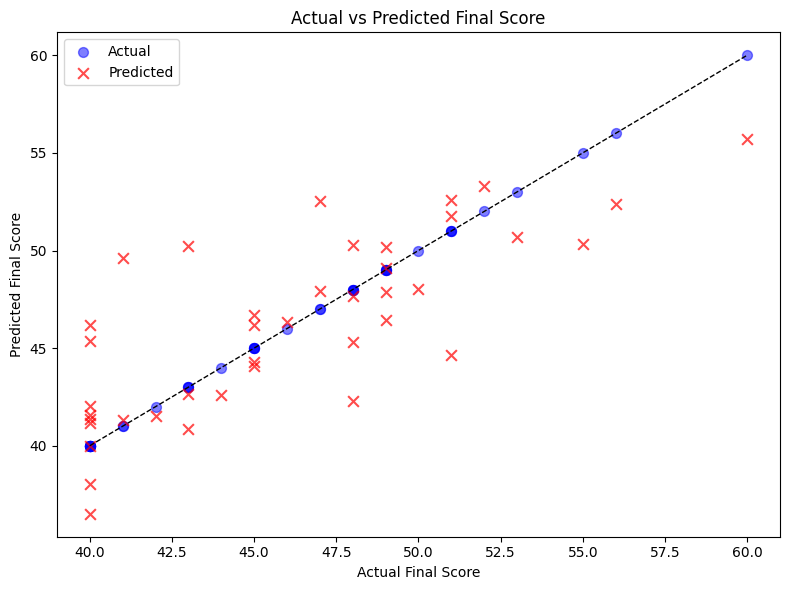

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='Actual', s=50)
plt.scatter(y_test, y_pred, color='red', marker='x', alpha=0.7, label='Predicted', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title('Actual vs Predicted Final Score')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#QUICK CHECKLIST

# Step 1 — Data Loading

# Load CSV with pd.read_csv()
# Print df.shape, df.columns, df.info()
# View first and last 5 rows
# Use df.describe() for statistical summary
# Check missing values with df.isnull().sum()
# Write 3 observations in markdown

# Step 2 — Data Cleaning

# Fix Gender using .str.title() → Male / Female
# Fix Name using .str.title() → Proper case
# Fix Department using .str.upper().str.strip()
# Fix Age: replace text with NaN, convert to numeric, fill with median
# Fix impossible values: Attendance_% <0 or >100 → NaN
# Fix impossible values: Final_Score >100 → NaN
# Fill missing numeric columns with median
# Remove duplicate rows using df.drop_duplicates()
# Final check: df.isnull().sum() = 0
# Comment/justify every decision

# Step 3 — EDA + Visualization

# Histplot: Final_Score, include 2-3 line interpretation
# Scatter: Attendance_% vs Final_Score
# Scatter: Study_Hours_Daily vs Final_Score
# Scatter: Midterm vs Final_Score
# Heatmap: correlations of numerical columns
# Boxplot: Final_Score by Department
# Countplot: students per Department
# Write 3 actionable insights

# Step 4 — Feature Engineering + Pipeline

# Create new feature: Total_Academic = Midterm + Assignments5 + Quizzes2
# Create Attendance_Category: bins [0,60,80,100] → labels Low/Medium/High
# Decide encoding for categorical features (One-Hot / Ordinal)
# Scale numerical columns using StandardScaler
# Drop Student_ID and Name
# Split dataset using train_test_split (test_size=0.2, random_state=42)
# Build ColumnTransformer + LinearRegression pipeline
# Fit pipeline on training data

# Step 5 — Model Building + Evaluation

# Predict on test set and print first 10 actual vs predicted
# Extract model and print coef_ and intercept_
# Identify feature with highest weight and interpret
# Calculate MAE, RMSE, R²
# Print clean Model Evaluation Report
# Scatter plot: Actual vs Predicted
# Write 2-line interpretation

# Deliverables

# IPYNB notebook with all steps clearly labeled
# Include all visualizations with interpretation
# Conclusion paragraph: model learning, R², and improvements
# GitHub repo with README explaining the project